# 08 · Tipos de datos, muestra del dataset y análisis bivariado

Este notebook produce los insumos del documento de **arquitectura de datos y análisis bivariado**:
1. **Esquema de las fuentes:** columnas, tipos de dato, vacíos y cardinalidad, calculados directamente de los archivos.
2. **Muestra representativa** del dataset de modelado, con el identificador del paciente enmascarado.
3. **Análisis bivariado** de las variables relevantes frente a la inasistencia, y entre variables.

> El análisis bivariado usa el **periodo de entrenamiento (enero–mayo de 2026)**, igual que el EDA, para no tomar decisiones con los meses de validación y test.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import funciones_inasistencia as fi
import funciones_modelado as fm

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
fm.estilo_graficos()

from scipy.stats import chi2_contingency, spearmanr
from sklearn.metrics import roc_auc_score
from pathlib import Path
Path("documentacion/figuras").mkdir(parents=True, exist_ok=True)

def guardar(fig, nombre):
    fig.savefig(f"documentacion/figuras/{nombre}.png", dpi=120, bbox_inches="tight")

## 1. Esquema de las fuentes de datos

In [2]:
fuentes = fi.cargar_fuentes(".")
filas = []
for nombre, df in fuentes.items():
    for columna in df.columns:
        serie = df[columna]
        tipo = str(serie.dtype)
        if tipo == "object":
            tipos_python = serie.dropna().map(lambda v: type(v).__name__).value_counts().index.tolist()
            tipo = "texto" if tipos_python == ["str"] else "mixto: " + ", ".join(tipos_python[:3])
        filas.append({"fuente": nombre, "columna": columna, "tipo": tipo, "registros": len(df),
                      "%_vacios": round(serie.isna().mean() * 100, 1), "valores_unicos": serie.nunique()})
esquema = pd.DataFrame(filas)
esquema.to_csv("documentacion/esquema_fuentes.csv", index=False, encoding="utf-8-sig")
esquema[esquema["fuente"] != "calendario"]

,fuente,columna,tipo,registros,%_vacios,valores_unicos
0,agendamiento,id_paciente,texto,576252,0.0,69493
1,agendamiento,sexo,texto,576252,0.0,2
2,agendamiento,nivel_usr,int64,576252,0.0,3
3,agendamiento,tipo_usuario,texto,576252,0.0,3
4,agendamiento,edad,int64,576252,0.0,105
5,agendamiento,nombre_cnt,texto,576252,0.0,11
6,agendamiento,turno,"mixto: time, str",576252,0.0,423
7,agendamiento,fecha_cita,datetime64[ns],576252,0.0,12438
8,agendamiento,fecha_asig,datetime64[ns],576252,0.0,201744
9,agendamiento,control,texto,576252,53.6,1


In [3]:
# Tipos de dato del dataset de modelado (dataset_modelo_v2.parquet)
dataset = pd.read_parquet("dataset_modelo_v2.parquet")
diccionario = pd.read_csv("diccionario_variables.csv")
tipos = pd.DataFrame({"variable": dataset.columns, "tipo": dataset.dtypes.astype(str).values})
tipos["tipo_analitico"] = np.select(
    [tipos["tipo"].str.contains("datetime"), tipos["tipo"] == "object",
     tipos["variable"].isin([c for c in dataset.columns if dataset[c].nunique() == 2 and dataset[c].dtype != object])],
    ["fecha", "categórica", "binaria"], default="numérica")
tipos = tipos.merge(diccionario, on="variable", how="left")
tipos.to_csv("documentacion/tipos_dataset_modelo.csv", index=False, encoding="utf-8-sig")
print(f"dataset_modelo_v2.parquet: {len(dataset):,} filas × {dataset.shape[1]} columnas")
tipos["tipo_analitico"].value_counts()

dataset_modelo_v2.parquet: 337,375 filas × 51 columnas


tipo_analitico
numérica      22
categórica    17
binaria       10
fecha          2
Name: count, dtype: int64

## 2. Muestra representativa del dataset
Muestra estratificada: 5 citas asistidas y 5 no asistidas del periodo de entrenamiento. **El identificador del paciente se enmascara** (solo se muestran los dos últimos dígitos) por tratarse de datos de salud.

In [4]:
train = dataset[dataset["particion"] == "train"].copy()
muestra = pd.concat([train[train["no_asiste"] == 0].sample(5, random_state=7),
                     train[train["no_asiste"] == 1].sample(5, random_state=7)])
columnas_muestra = ["id_paciente", "fecha_cita", "servicio_homologado", "lead_time", "edad", "sexo", "tipo_usuario",
                    "sede", "dia_semana", "programa_rcv", "n_citas_previas", "tasa_inasistencia_suavizada",
                    "estado_ultima_cita", "no_asiste"]
muestra = muestra[columnas_muestra].copy()
muestra["id_paciente"] = "****" + muestra["id_paciente"].str[-2:]
muestra["fecha_cita"] = muestra["fecha_cita"].dt.date
muestra["tasa_inasistencia_suavizada"] = muestra["tasa_inasistencia_suavizada"].round(3)
muestra.to_csv("documentacion/muestra_dataset.csv", index=False, encoding="utf-8-sig")
muestra

,id_paciente,fecha_cita,servicio_homologado,lead_time,edad,sexo,tipo_usuario,sede,dia_semana,programa_rcv,n_citas_previas,tasa_inasistencia_suavizada,estado_ultima_cita,no_asiste
55640,****28,2026-01-13,NUTRICIONISTA,3,39,Femenino,COTIZANTE,LAURELES,Martes,Sin programa,1,0.240,Asistió,0
305396,****14,2026-01-29,PEDIATRIA,7,0,Femenino,BENEFICIARIO,LAURELES,Jueves,Sin programa,2,0.592,No asistió,0
276621,****87,2026-02-25,MEDICINA GENERAL,7,45,Masculino,COTIZANTE,ARMENIA,Miércoles,Programa de Hipertension,3,0.327,No asistió,0
57659,****18,2026-03-30,MEDICINA GENERAL,14,35,Femenino,COTIZANTE,LAURELES,Lunes,Sin programa,0,0.320,Sin historial,0
261203,****64,2026-03-10,MEDICINA GENERAL,4,53,Masculino,BENEFICIARIO,CENTRO,Martes,Sin programa,1,0.490,No asistió,0
281115,****00,2026-05-26,MEDICINA GENERAL,5,42,Masculino,BENEFICIARIO,CENTRO,Martes,Sin programa,10,0.305,Asistió,1
308328,****27,2026-03-19,PYP CURSO DE VIDA - MEDICO,7,8,Femenino,BENEFICIARIO,CENTRO,Jueves,Sin programa,3,0.327,No asistió,1
277438,****18,2026-01-30,MEDICINA GENERAL,2,49,Masculino,COTIZANTE,CENTRO,Viernes,Sin programa,0,0.320,Sin historial,1
224992,****27,2026-03-20,ODONTOLOGIA,9,40,Femenino,COTIZANTE,ARMENIA,Viernes,Programa de Hipertension,5,0.620,No asistió,1
17119,****46,2026-01-21,CRONICOS - MEDICO,92,80,Masculino,COTIZANTE,LAURELES,Miércoles,Programa de Hipertension,0,0.320,Sin historial,1


## 3. Análisis bivariado: cada variable frente a la inasistencia

**¿Cómo medir la fuerza de la relación?** Depende del tipo de variable:
- **Categórica vs. inasistencia → V de Cramér** (de 0 = sin relación a 1 = relación perfecta), basada en la prueba chi-cuadrado. Como referencia práctica: < 0,1 débil, 0,1–0,3 moderada.
- **Numérica vs. inasistencia → AUC univariada:** si ordenamos las citas solo por esa variable, ¿qué tan bien separa asistidas de no asistidas? 0,5 = nada. Mostramos |AUC − 0,5|: más alto = más fuerte (sea la relación positiva o negativa).

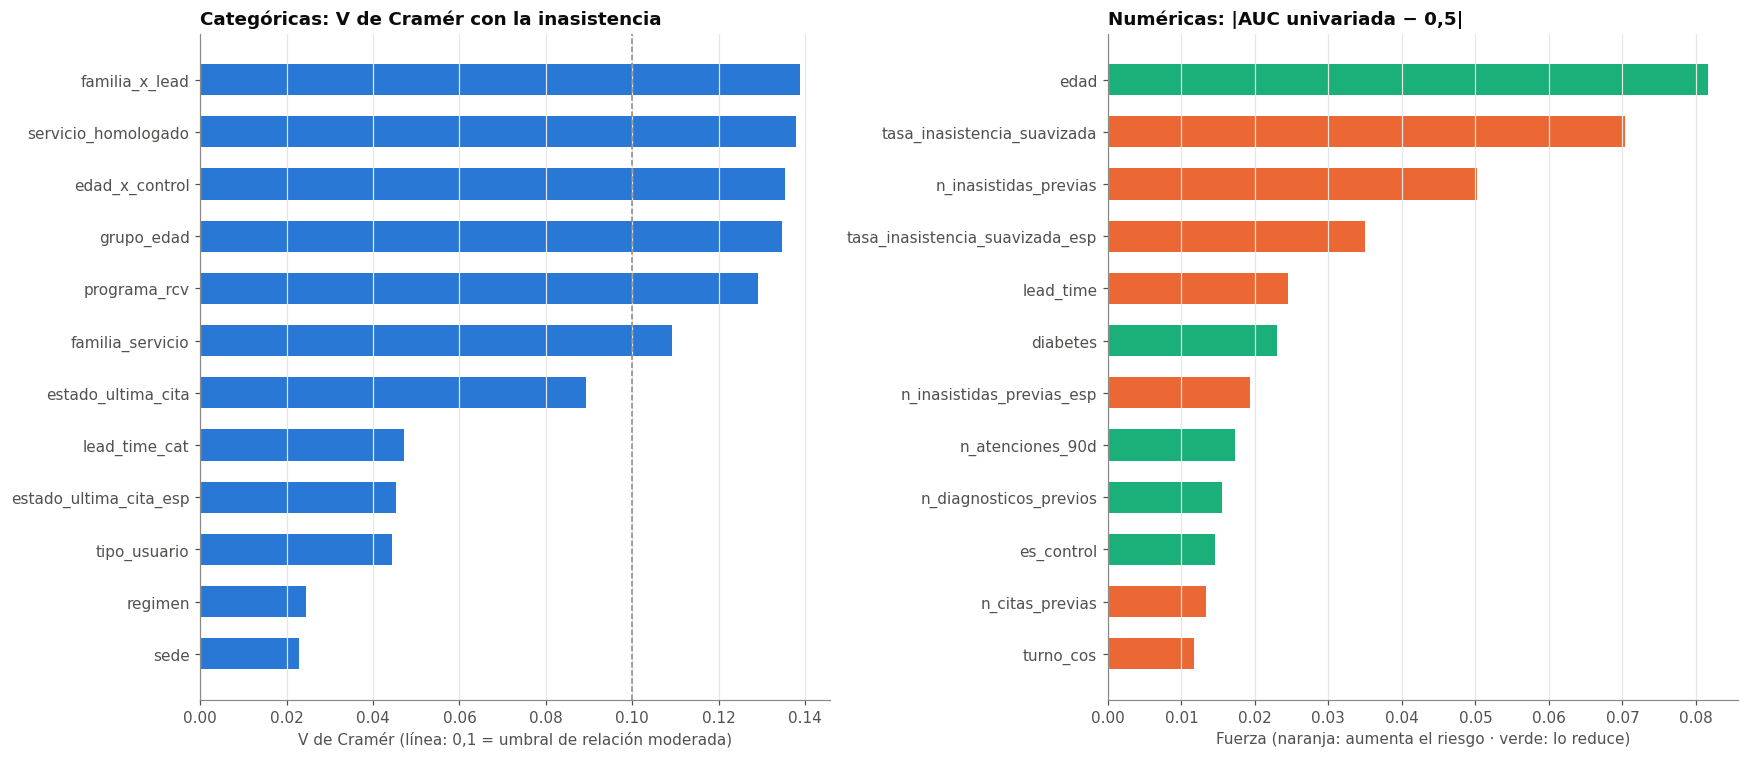

,variable,V_cramer,p_valor
13,familia_x_lead,0.1389,0.0
2,servicio_homologado,0.1380,0.0
14,edad_x_control,0.1355,0.0
4,grupo_edad,0.1347,0.0
11,programa_rcv,0.1291,0.0
3,familia_servicio,0.1091,0.0
10,estado_ultima_cita,0.0894,0.0
0,lead_time_cat,0.0472,0.0
12,estado_ultima_cita_esp,0.0452,0.0
6,tipo_usuario,0.0443,0.0


,variable,AUC_univariada,fuerza,direccion
4,edad,0.418,0.082,"↑ más valor, menos inasistencia"
15,tasa_inasistencia_suavizada,0.570,0.070,"↑ más valor, más inasistencia"
14,n_inasistidas_previas,0.550,0.050,"↑ más valor, más inasistencia"
25,tasa_inasistencia_suavizada_esp,0.535,0.035,"↑ más valor, más inasistencia"
0,lead_time,0.525,0.025,"↑ más valor, más inasistencia"
18,diabetes,0.477,0.023,"↑ más valor, menos inasistencia"
24,n_inasistidas_previas_esp,0.519,0.019,"↑ más valor, más inasistencia"
22,n_atenciones_90d,0.483,0.017,"↑ más valor, menos inasistencia"
21,n_diagnosticos_previos,0.484,0.016,"↑ más valor, menos inasistencia"
3,es_control,0.485,0.015,"↑ más valor, menos inasistencia"


In [5]:
y = train["no_asiste"]
categoricas = [c for c in train.columns if train[c].dtype == object and c not in ["id_paciente", "particion"]]
numericas = [c for c in train.columns if train[c].dtype != object and c not in ["cita_id", "no_asiste", "fecha_cita", "fecha_asig"]]

def v_cramer(x):
    tabla = pd.crosstab(x, y)
    chi2, p, _, _ = chi2_contingency(tabla)
    return np.sqrt(chi2 / (tabla.values.sum() * (min(tabla.shape) - 1))), p

asociacion_cat = pd.DataFrame([(c, *v_cramer(train[c])) for c in categoricas], columns=["variable", "V_cramer", "p_valor"]) \
    .sort_values("V_cramer", ascending=False)

filas = []
for c in numericas:
    valido = train[c].notna()
    auc = roc_auc_score(y[valido], train.loc[valido, c])
    filas.append({"variable": c, "AUC_univariada": auc, "fuerza": abs(auc - 0.5),
                  "direccion": "↑ más valor, más inasistencia" if auc > 0.5 else "↑ más valor, menos inasistencia"})
asociacion_num = pd.DataFrame(filas).sort_values("fuerza", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
top_cat = asociacion_cat.head(12)
axes[0].barh(top_cat["variable"], top_cat["V_cramer"], color=fm.AZUL, height=0.6)
axes[0].invert_yaxis()
axes[0].axvline(0.1, color=fm.GRIS, linestyle="--", linewidth=1)
axes[0].set_title("Categóricas: V de Cramér con la inasistencia")
axes[0].set_xlabel("V de Cramér (línea: 0,1 = umbral de relación moderada)")
top_num = asociacion_num.head(12)
colores = [fm.NARANJA if a > 0.5 else fm.AQUA for a in top_num["AUC_univariada"]]
axes[1].barh(top_num["variable"], top_num["fuerza"], color=colores, height=0.6)
axes[1].invert_yaxis()
axes[1].set_title("Numéricas: |AUC univariada − 0,5|")
axes[1].set_xlabel("Fuerza (naranja: aumenta el riesgo · verde: lo reduce)")
for ax in axes:
    ax.grid(axis="y", visible=False)
plt.tight_layout()
guardar(fig, "16_fuerza_asociacion")
plt.show()
display(asociacion_cat.round(4))
asociacion_num.round(3)

## 4. Variables numéricas frente a la inasistencia
Para cada variable numérica, la tasa de inasistencia por rangos (con intervalo de confianza del 95 %) muestra la **forma** de la relación: lineal, con un pico o plana. Los diagramas de caja comparan la distribución entre citas asistidas y no asistidas.

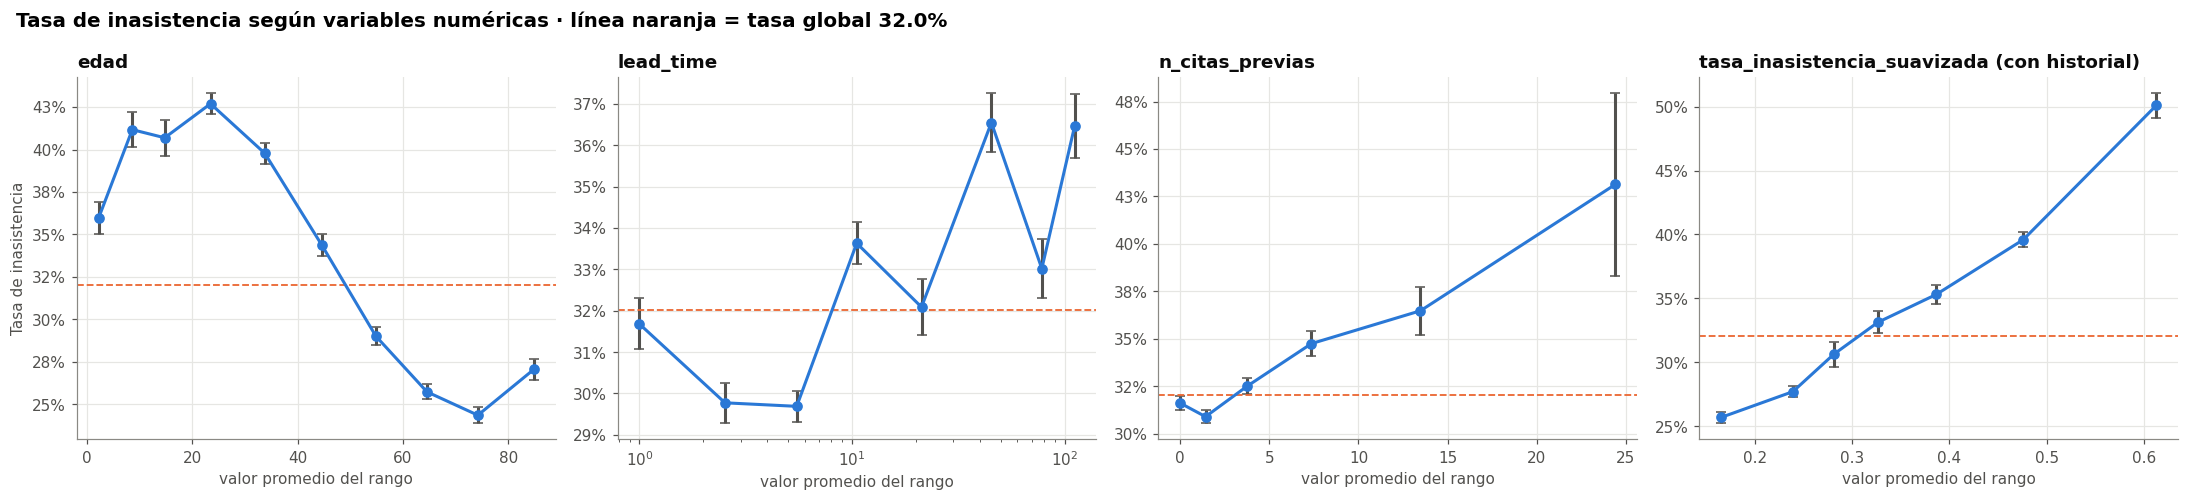

Pacientes sin historial: tasa de inasistencia 31.6%
edad → 2.2: 36.0% | 8.6: 41.2% | 14.7: 40.7% | 23.4: 42.7% | 33.7: 39.8% | 44.6: 34.4% | 54.9: 29.0% | 64.5: 25.7% | 74.2: 24.4% | 84.8: 27.1%
lead_time → 1.0: 31.7% | 2.5: 29.8% | 5.5: 29.7% | 10.5: 33.6% | 21.2: 32.1% | 45.3: 36.5% | 78.1: 33.0% | 111.4: 36.5%
n_citas_previas → 0.0: 31.6% | 1.4: 30.9% | 3.8: 32.5% | 7.4: 34.7% | 13.5: 36.5% | 24.4: 43.1%
tasa_inasistencia_suavizada → 0.2: 25.7% | 0.2: 27.7% | 0.3: 30.6% | 0.3: 33.1% | 0.4: 35.3% | 0.5: 39.6% | 0.6: 50.1%


In [6]:
rangos = {
    "edad": [-1, 5, 11, 17, 28, 39, 49, 59, 69, 79, 120],
    "lead_time": [0, 1, 3, 7, 14, 30, 60, 90, 400],
    "n_citas_previas": [-1, 0, 2, 5, 10, 20, 500],
    "tasa_inasistencia_suavizada": [0, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 1],
}
# Para la tasa histórica se excluyen los pacientes SIN historial: todos tienen el mismo valor inicial (el promedio
# general), lo que distorsiona la curva. Su tasa se reporta aparte.
tasa_global = y.mean()
fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))
tablas_rango = {}
for ax, (variable, cortes) in zip(axes, rangos.items()):
    datos = train[train["n_citas_previas"] >= 1] if variable == "tasa_inasistencia_suavizada" else train
    grupos = pd.cut(datos[variable], cortes)
    tabla = datos.groupby(grupos, observed=True).agg(tasa=("no_asiste", "mean"), citas=("no_asiste", "size"),
                                                   valor_medio=(variable, "mean")).reset_index(drop=True)
    tabla["ic95"] = fm.intervalo_confianza(tabla["tasa"], tabla["citas"])
    tablas_rango[variable] = tabla
    ax.errorbar(tabla["valor_medio"], tabla["tasa"], yerr=tabla["ic95"], color=fm.AZUL, marker="o", markersize=6,
                linewidth=2, capsize=3, ecolor=fm.TINTA_SUAVE)
    ax.axhline(tasa_global, color=fm.NARANJA, linestyle="--", linewidth=1.2)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_title(variable + (" (con historial)" if variable == "tasa_inasistencia_suavizada" else ""))
    ax.set_xlabel("valor promedio del rango")
    if variable == "lead_time":
        ax.set_xscale("log")
axes[0].set_ylabel("Tasa de inasistencia")
fig.suptitle(f"Tasa de inasistencia según variables numéricas · línea naranja = tasa global {tasa_global:.1%}",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
guardar(fig, "17_numericas_vs_inasistencia")
plt.show()
print(f"Pacientes sin historial: tasa de inasistencia {train.loc[train['n_citas_previas'] == 0, 'no_asiste'].mean():.1%}")
for variable, tabla in tablas_rango.items():
    print(variable, "→", " | ".join(f"{v:.1f}: {t:.1%}" for v, t in zip(tabla["valor_medio"], tabla["tasa"])))

edad: mediana asistió = 58.00 | no asistió = 45.00
tasa_inasistencia_suavizada: mediana asistió = 0.24 | no asistió = 0.33
lead_time: mediana asistió = 7.00 | no asistió = 8.00


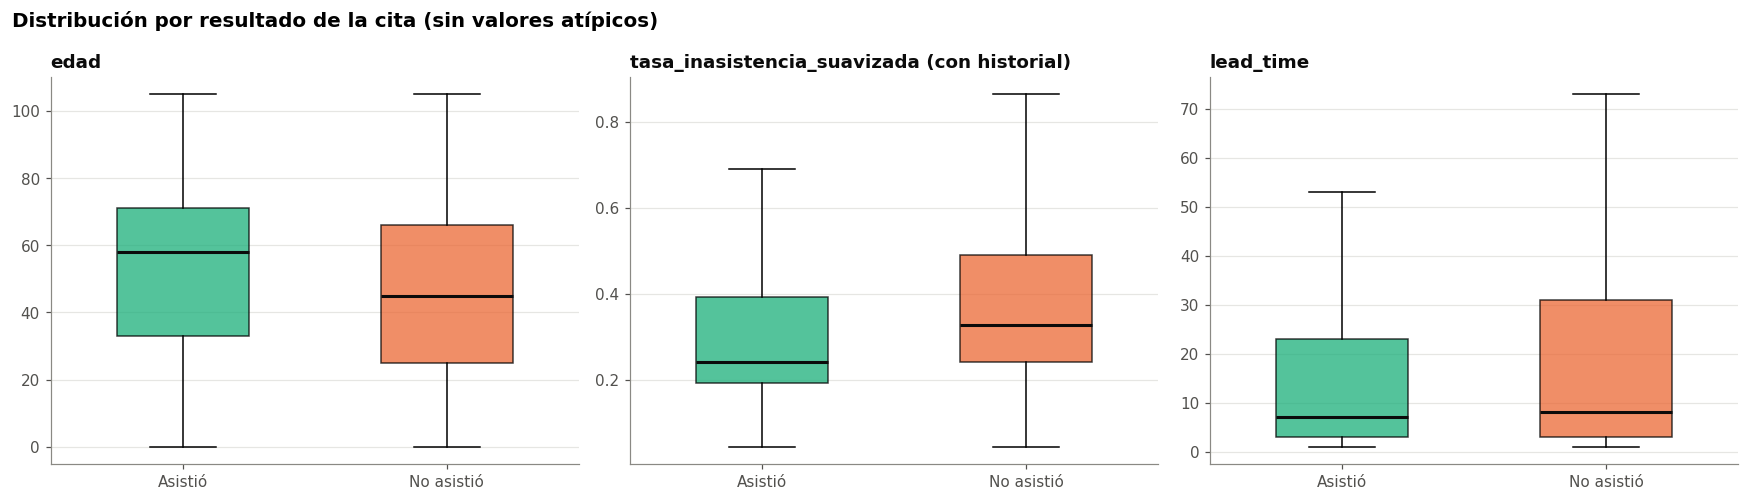

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
etiquetas = {0: "Asistió", 1: "No asistió"}
for ax, variable in zip(axes, ["edad", "tasa_inasistencia_suavizada", "lead_time"]):
    base = train[train["n_citas_previas"] >= 1] if variable == "tasa_inasistencia_suavizada" else train
    datos = [base.loc[base["no_asiste"] == clase, variable].dropna() for clase in [0, 1]]
    caja = ax.boxplot(datos, labels=[etiquetas[0], etiquetas[1]], patch_artist=True, showfliers=False, widths=0.5,
                      medianprops={"color": fm.TINTA, "linewidth": 2})
    for parche, color in zip(caja["boxes"], [fm.AQUA, fm.NARANJA]):
        parche.set_facecolor(color)
        parche.set_alpha(0.75)
    ax.set_title(variable + (" (con historial)" if variable == "tasa_inasistencia_suavizada" else ""))
    ax.grid(axis="x", visible=False)
    medianas = [d.median() for d in datos]
    print(f"{variable}: mediana asistió = {medianas[0]:.2f} | no asistió = {medianas[1]:.2f}")
fig.suptitle("Distribución por resultado de la cita (sin valores atípicos)", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
guardar(fig, "18_cajas_por_resultado")
plt.show()

## 5. Interacciones entre variables categóricas
Un mapa de calor de la tasa de inasistencia para cada combinación de dos variables permite ver si **el efecto de una variable depende de la otra**. Las celdas con menos de 100 citas se dejan en blanco porque no son confiables.

### 5.1 ¿Los crónicos faltan menos solo porque son mayores?
En el EDA quedó la duda: los pacientes de programas RCV son en su mayoría adultos mayores, que ya de por sí faltan menos. Comparamos **dentro de cada grupo de edad**.

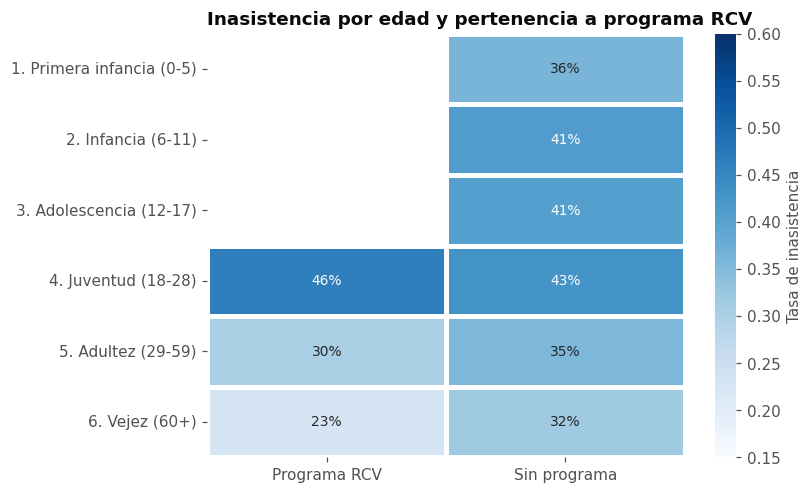

,programa_RCV,sin_programa,citas_programa,diferencia_pp
grupo_edad,,,,
4. Juventud (18-28),0.464,0.426,601,3.822
5. Adultez (29-59),0.303,0.354,18759,-5.159
6. Vejez (60+),0.227,0.318,62428,-9.116


In [8]:
def mapa_tasa(df, filas, columnas, ax, titulo, minimo=100):
    tasa = df.pivot_table(index=filas, columns=columnas, values="no_asiste", aggfunc="mean")
    conteo = df.pivot_table(index=filas, columns=columnas, values="no_asiste", aggfunc="size")
    tasa = tasa.where(conteo >= minimo)
    sns.heatmap(tasa, cmap="Blues", vmin=0.15, vmax=0.6, annot=True, fmt=".0%", ax=ax, linewidths=2, linecolor="white",
                cbar_kws={"label": "Tasa de inasistencia"}, annot_kws={"fontsize": 9})
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)
    return tasa, conteo

train["pertenece_rcv"] = np.where(train["programa_rcv"].isin(["Programa de Diabetes", "Programa de Hipertension",
                                                               "Programa de Nefroproteccion"]), "Programa RCV", "Sin programa")
fig, ax = plt.subplots(figsize=(7, 5))
tasa_rcv, conteo_rcv = mapa_tasa(train, "grupo_edad", "pertenece_rcv", ax, "Inasistencia por edad y pertenencia a programa RCV")
guardar(fig, "19_edad_x_programa")
plt.show()
comparacion = pd.DataFrame({"programa_RCV": tasa_rcv["Programa RCV"], "sin_programa": tasa_rcv["Sin programa"],
                            "citas_programa": conteo_rcv["Programa RCV"]})
comparacion["diferencia_pp"] = (comparacion["programa_RCV"] - comparacion["sin_programa"]) * 100
comparacion.dropna().round(3)

### 5.2 ¿El efecto del tiempo de espera (lead time) es igual en todos los servicios?

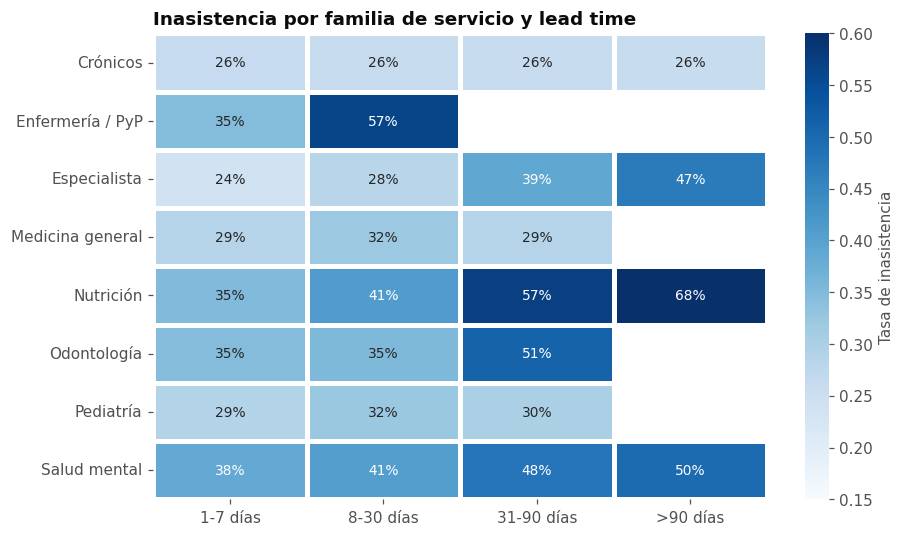

lead_time_cat,1-7 días,8-30 días,31-90 días,>90 días,cambio_1-7_a_31-90_pp
familia_servicio,,,,,
Crónicos,0.264,0.261,0.261,0.259,-0.330
Enfermería / PyP,0.349,0.566,NaN,NaN,NaN
Especialista,0.237,0.282,0.391,0.471,15.329
Medicina general,0.286,0.321,0.286,NaN,0.036
Nutrición,0.352,0.411,0.572,0.676,22.004
Odontología,0.346,0.353,0.512,NaN,16.574
Pediatría,0.289,0.324,0.301,NaN,1.165
Salud mental,0.385,0.408,0.481,0.499,9.619


In [9]:
orden_lead = ["1-7 días", "8-30 días", "31-90 días", ">90 días"]
fig, ax = plt.subplots(figsize=(9, 5.5))
tasa_lead, conteo_lead = mapa_tasa(train.assign(lead_time_cat=pd.Categorical(train["lead_time_cat"], orden_lead)),
                                   "familia_servicio", "lead_time_cat", ax, "Inasistencia por familia de servicio y lead time")
guardar(fig, "20_servicio_x_leadtime")
plt.show()
tasa_lead["cambio_1-7_a_31-90_pp"] = (tasa_lead["31-90 días"] - tasa_lead["1-7 días"]) * 100
tasa_lead.round(3)

### 5.3 Edad y servicio

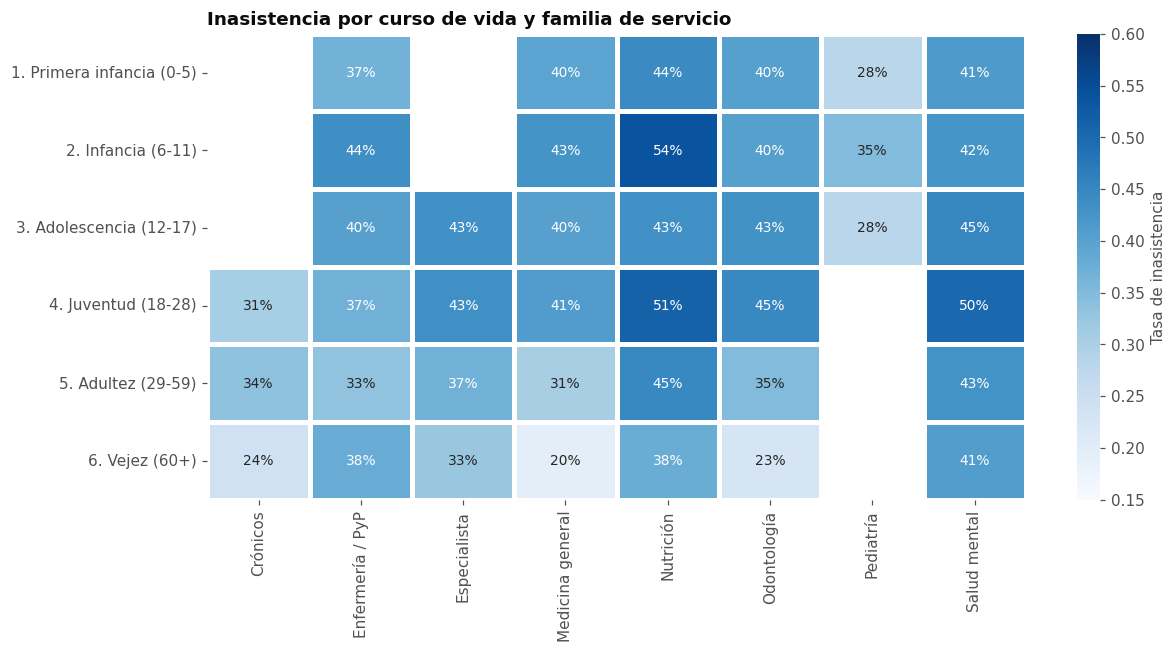

In [10]:
fig, ax = plt.subplots(figsize=(12, 5.5))
tasa_edad_servicio, _ = mapa_tasa(train, "grupo_edad", "familia_servicio", ax, "Inasistencia por curso de vida y familia de servicio")
guardar(fig, "21_edad_x_servicio")
plt.show()

## 6. Relaciones entre variables numéricas

### 6.1 Correlación de Spearman entre predictores
Spearman mide si dos variables crecen juntas, aunque la relación no sea lineal. Correlaciones altas entre predictores indican **información redundante**.

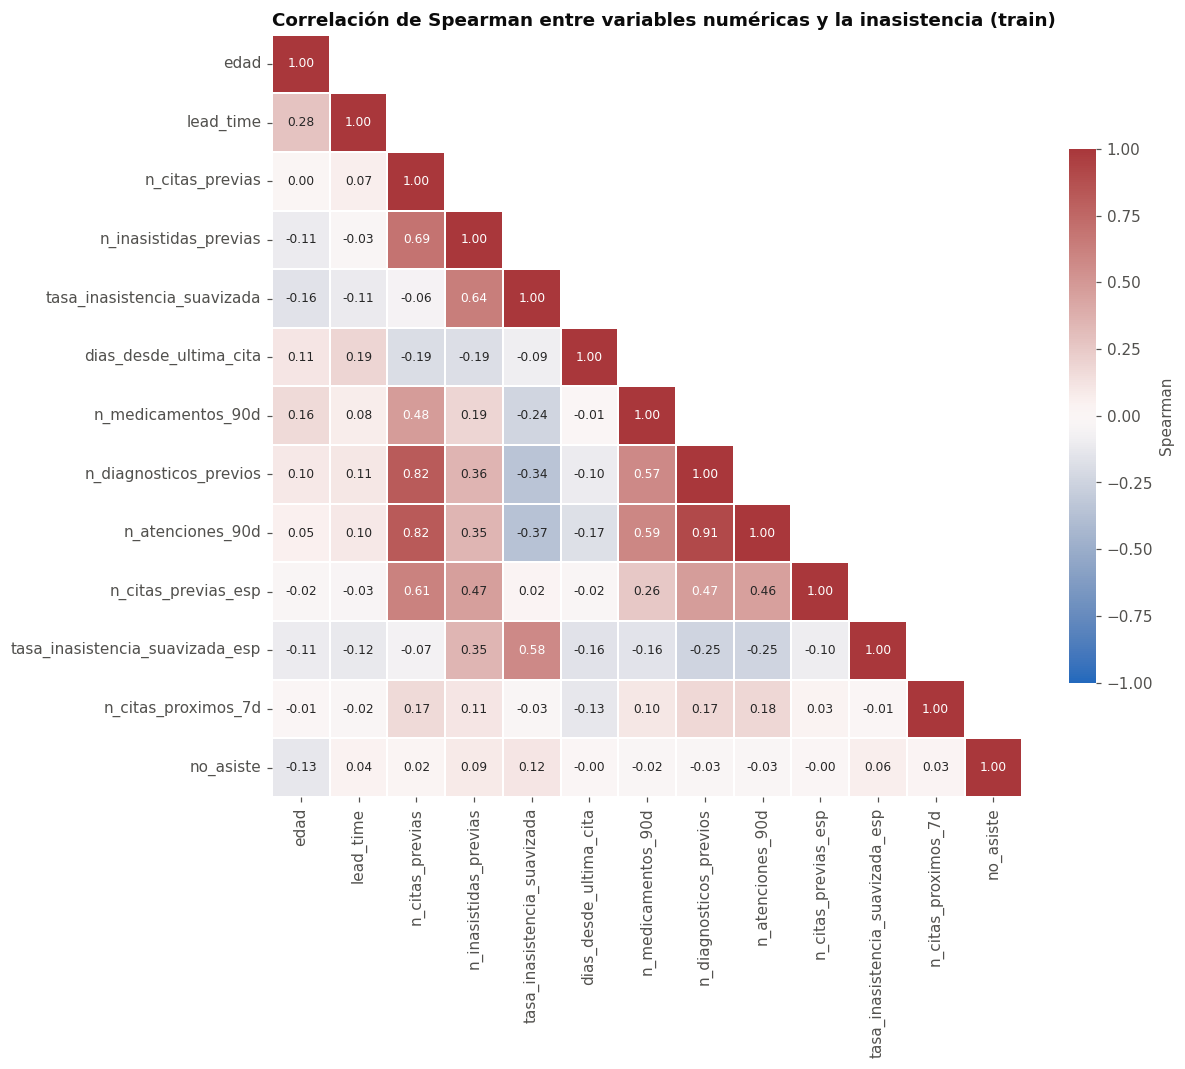

,variable_1,variable_2,spearman
8,n_diagnosticos_previos,n_atenciones_90d,0.91
2,n_citas_previas,n_atenciones_90d,0.82
1,n_citas_previas,n_diagnosticos_previos,0.82
0,n_citas_previas,n_inasistidas_previas,0.69
4,n_inasistidas_previas,tasa_inasistencia_suavizada,0.64
3,n_citas_previas,n_citas_previas_esp,0.61
7,n_medicamentos_90d,n_atenciones_90d,0.59
5,tasa_inasistencia_suavizada,tasa_inasistencia_suavizada_esp,0.58
6,n_medicamentos_90d,n_diagnosticos_previos,0.57


In [11]:
seleccion = ["edad", "lead_time", "n_citas_previas", "n_inasistidas_previas", "tasa_inasistencia_suavizada",
             "dias_desde_ultima_cita", "n_medicamentos_90d", "n_diagnosticos_previos", "n_atenciones_90d",
             "n_citas_previas_esp", "tasa_inasistencia_suavizada_esp", "n_citas_proximos_7d", "no_asiste"]
correlacion = train[seleccion].corr(method="spearman")
fig, ax = plt.subplots(figsize=(11, 9))
mascara = np.triu(np.ones_like(correlacion, dtype=bool), k=1)
sns.heatmap(correlacion, mask=mascara, cmap="vlag", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax,
            linewidths=1, linecolor="white", annot_kws={"fontsize": 8}, cbar_kws={"shrink": 0.7, "label": "Spearman"})
ax.set_title("Correlación de Spearman entre variables numéricas y la inasistencia (train)")
ax.grid(False)
guardar(fig, "22_correlacion_spearman")
plt.show()
pares = [(a, b, correlacion.loc[a, b]) for i, a in enumerate(seleccion) for b in seleccion[i + 1:] if abs(correlacion.loc[a, b]) >= 0.5]
pd.DataFrame(pares, columns=["variable_1", "variable_2", "spearman"]).sort_values("spearman", key=abs, ascending=False).round(2)

### 6.2 Dispersión: edad vs. historial de inasistencia
Con más de 200 mil citas, un gráfico de puntos se satura. Usamos un **hexbin**: cada hexágono agrupa las citas con una edad y una tasa histórica parecidas, y su color es la **tasa de inasistencia real** de ese grupo. Solo se muestran hexágonos con al menos 30 citas.

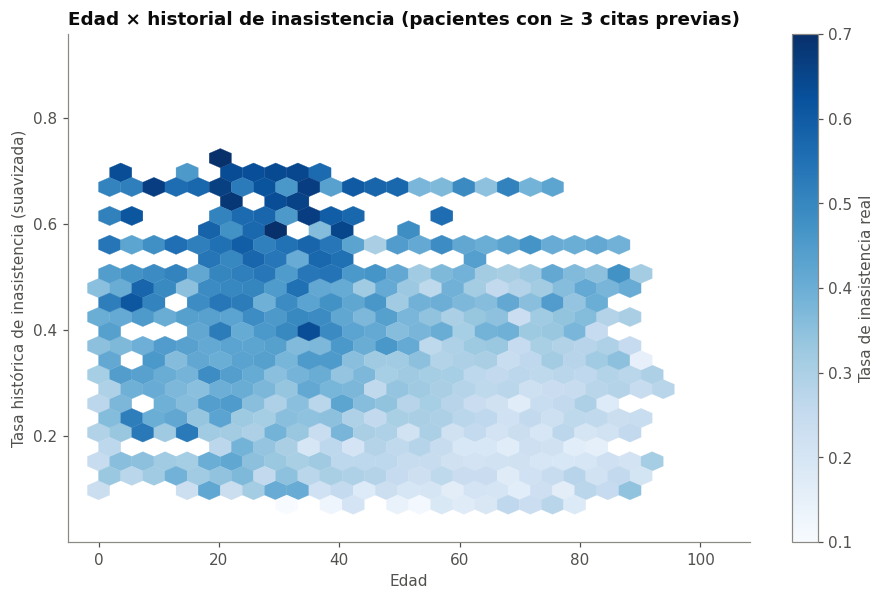

Spearman edad vs. tasa histórica (≥3 citas previas): -0.22 | citas: 74,965


joven,> 28 años,≤ 28 años
historial,,
bajo (<25 %),0.241,0.345
medio (25-40 %),0.310,0.402
alto (>40 %),0.420,0.512


In [12]:
con_historial = train[train["n_citas_previas"] >= 3]
fig, ax = plt.subplots(figsize=(10, 6))
hexagonos = ax.hexbin(con_historial["edad"], con_historial["tasa_inasistencia_suavizada"], C=con_historial["no_asiste"],
                      reduce_C_function=np.mean, gridsize=28, mincnt=30, cmap="Blues", vmin=0.1, vmax=0.7, linewidths=0.2)
barra = fig.colorbar(hexagonos, ax=ax)
barra.set_label("Tasa de inasistencia real")
ax.set_xlabel("Edad")
ax.set_ylabel("Tasa histórica de inasistencia (suavizada)")
ax.set_title("Edad × historial de inasistencia (pacientes con ≥ 3 citas previas)")
ax.grid(False)
guardar(fig, "23_hexbin_edad_historial")
plt.show()

rho_edad_hist = spearmanr(con_historial["edad"], con_historial["tasa_inasistencia_suavizada"]).correlation
print(f"Spearman edad vs. tasa histórica (≥3 citas previas): {rho_edad_hist:.2f} | citas: {len(con_historial):,}")
tabla = con_historial.assign(joven=np.where(con_historial["edad"] <= 28, "≤ 28 años", "> 28 años"),
                             historial=pd.cut(con_historial["tasa_inasistencia_suavizada"], [0, 0.25, 0.4, 1],
                                              labels=["bajo (<25 %)", "medio (25-40 %)", "alto (>40 %)"]))
tabla.pivot_table(index="historial", columns="joven", values="no_asiste", aggfunc="mean", observed=True).round(3)

### 6.3 Dispersión a nivel de servicio: inasistencia vs. valor del cupo
Cada punto es un servicio (tamaño = número de citas). Esta relación es clave para el análisis financiero (notebook 07): si los servicios que más faltan son los de menor valor, **priorizar por riesgo no es lo mismo que priorizar por dinero**.

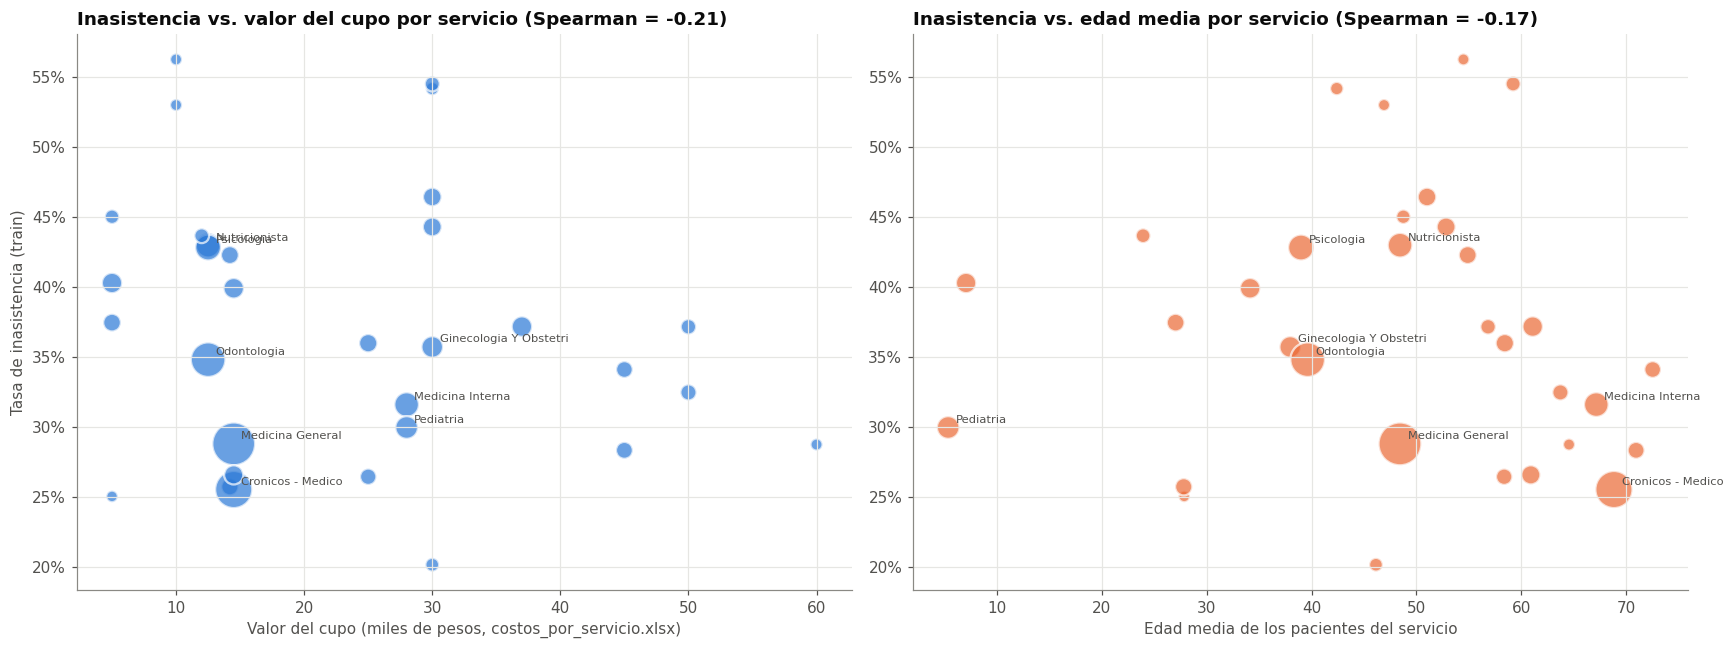

Servicios con ≥300 citas: 32 | Spearman valor-tasa = -0.21 | Spearman edad-tasa = -0.17


In [13]:
costos = pd.read_excel("modelos/costos_por_servicio.xlsx", sheet_name="costos")[["servicio_homologado", "valor_cupo_COP"]]
por_servicio = (train.groupby(["servicio_homologado", "familia_servicio"])
                .agg(citas=("no_asiste", "size"), tasa=("no_asiste", "mean"), lead_medio=("lead_time", "mean"),
                     edad_media=("edad", "mean")).reset_index()
                .merge(costos, on="servicio_homologado", how="left"))
por_servicio = por_servicio[por_servicio["citas"] >= 300]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
if por_servicio["valor_cupo_COP"].notna().sum() >= 5:
    datos = por_servicio.dropna(subset=["valor_cupo_COP"])
    axes[0].scatter(datos["valor_cupo_COP"] / 1000, datos["tasa"], s=np.sqrt(datos["citas"]) * 3, color=fm.AZUL,
                    alpha=0.7, edgecolor="white", linewidth=1.5)
    for _, fila in datos.nlargest(8, "citas").iterrows():
        axes[0].annotate(fila["servicio_homologado"].title()[:22], (fila["valor_cupo_COP"] / 1000, fila["tasa"]),
                         fontsize=7.5, color=fm.TINTA_SUAVE, xytext=(5, 3), textcoords="offset points")
    rho_valor = spearmanr(datos["valor_cupo_COP"], datos["tasa"]).correlation
    axes[0].set_xlabel("Valor del cupo (miles de pesos, costos_por_servicio.xlsx)")
    axes[0].set_title(f"Inasistencia vs. valor del cupo por servicio (Spearman = {rho_valor:.2f})")
else:
    rho_valor = np.nan
    axes[0].text(0.5, 0.5, "Sin valores por servicio en costos_por_servicio.xlsx", ha="center", transform=axes[0].transAxes)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].set_ylabel("Tasa de inasistencia (train)")

axes[1].scatter(por_servicio["edad_media"], por_servicio["tasa"], s=np.sqrt(por_servicio["citas"]) * 3, color=fm.NARANJA,
                alpha=0.7, edgecolor="white", linewidth=1.5)
for _, fila in por_servicio.nlargest(8, "citas").iterrows():
    axes[1].annotate(fila["servicio_homologado"].title()[:22], (fila["edad_media"], fila["tasa"]), fontsize=7.5,
                     color=fm.TINTA_SUAVE, xytext=(5, 3), textcoords="offset points")
rho_edad_servicio = spearmanr(por_servicio["edad_media"], por_servicio["tasa"]).correlation
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[1].set_xlabel("Edad media de los pacientes del servicio")
axes[1].set_title(f"Inasistencia vs. edad media por servicio (Spearman = {rho_edad_servicio:.2f})")
plt.tight_layout()
guardar(fig, "24_dispersion_servicios")
plt.show()
print(f"Servicios con ≥300 citas: {len(por_servicio)} | Spearman valor-tasa = {rho_valor:.2f} | Spearman edad-tasa = {rho_edad_servicio:.2f}")

## 7. Resumen de hallazgos (calculado)

In [14]:
edad_t = tablas_rango["edad"]
pico = edad_t.loc[edad_t["tasa"].idxmax()]
lead_t = tablas_rango["lead_time"]
prev_t = tablas_rango["n_citas_previas"]
hist_t = tablas_rango["tasa_inasistencia_suavizada"]
vejez = comparacion.loc["6. Vejez (60+)"]
adultez = comparacion.loc["5. Adultez (29-59)"]
print(f"1. Variables con mayor asociación: categóricas → {', '.join(asociacion_cat.head(5)['variable'])} "
      f"(V de Cramér {asociacion_cat['V_cramer'].iloc[4]:.2f}–{asociacion_cat['V_cramer'].iloc[0]:.2f}); "
      f"numéricas → {', '.join(asociacion_num.head(3)['variable'])}.")
print(f"2. Edad: relación en forma de campana; pico de {pico['tasa']:.1%} alrededor de {pico['valor_medio']:.0f} años; "
      f"mínimo de {edad_t['tasa'].min():.1%}.")
print(f"3. Historial (pacientes con citas previas): tasa histórica < 0,20 → {hist_t['tasa'].iloc[0]:.1%}; > 0,50 → {hist_t['tasa'].iloc[-1]:.1%}.")
print(f"4. Citas previas: {prev_t['tasa'].iloc[0]:.1%} sin historial → {prev_t['tasa'].iloc[-1]:.1%} con más de 20 citas previas.")
print(f"5. Lead time: {lead_t['tasa'].min():.1%} (mínimo) a {lead_t['tasa'].max():.1%} (máximo): efecto global pequeño.")
print(f"6. Programa RCV dentro de la misma edad: vejez {vejez['programa_RCV']:.1%} vs. {vejez['sin_programa']:.1%} "
      f"({vejez['diferencia_pp']:+.1f} pp); adultez {adultez['programa_RCV']:.1%} vs. {adultez['sin_programa']:.1%} ({adultez['diferencia_pp']:+.1f} pp).")
print(f"7. Lead time por servicio: cambio de 1-7 a 31-90 días → " +
      ", ".join(f"{i}: {v:+.1f} pp" for i, v in tasa_lead["cambio_1-7_a_31-90_pp"].dropna().items()))
print(f"8. Servicios: Spearman valor del cupo vs. inasistencia = {rho_valor:.2f}; edad media vs. inasistencia = {rho_edad_servicio:.2f}.")

1. Variables con mayor asociación: categóricas → familia_x_lead, servicio_homologado, edad_x_control, grupo_edad, programa_rcv (V de Cramér 0.13–0.14); numéricas → edad, tasa_inasistencia_suavizada, n_inasistidas_previas.
2. Edad: relación en forma de campana; pico de 42.7% alrededor de 23 años; mínimo de 24.4%.
3. Historial (pacientes con citas previas): tasa histórica < 0,20 → 25.7%; > 0,50 → 50.1%.
4. Citas previas: 31.6% sin historial → 43.1% con más de 20 citas previas.
5. Lead time: 29.7% (mínimo) a 36.5% (máximo): efecto global pequeño.
6. Programa RCV dentro de la misma edad: vejez 22.7% vs. 31.8% (-9.1 pp); adultez 30.3% vs. 35.4% (-5.2 pp).
7. Lead time por servicio: cambio de 1-7 a 31-90 días → Crónicos: -0.3 pp, Especialista: +15.3 pp, Medicina general: +0.0 pp, Nutrición: +22.0 pp, Odontología: +16.6 pp, Pediatría: +1.2 pp, Salud mental: +9.6 pp
8. Servicios: Spearman valor del cupo vs. inasistencia = -0.21; edad media vs. inasistencia = -0.17.
